# Retrieval Experimentation Notebook

This notebook evaluates different retrieval approaches for the Yoga RAG system:

- Text-based search (BM25/TF-IDF)
- Vector-based semantic search
- Hybrid search (combination of text and vector)

We'll use the ground truth dataset to calculate:

- **Hit Rate**: Percentage of queries where at least one relevant document is in top-k results
- **MRR (Mean Reciprocal Rank)**: Average of 1/rank of first relevant document

Target metrics: Hit Rate > 90%, MRR > 0.85


## Setup and Imports


In [1]:
import pandas as pd
import numpy as np
from typing import List, Dict, Tuple
import warnings

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

## Load Data


In [2]:
# Load yoga poses dataset
yoga_data = pd.read_csv("../data/yoga_data_merged.csv")
print(f"Loaded {len(yoga_data)} yoga poses")
print(f"\nColumns: {list(yoga_data.columns)}")
print(f"\nFirst few rows:")
yoga_data.head()

Loaded 202 yoga poses

Columns: ['id', 'pose_name', 'sanskrit_name', 'category', 'difficulty_level', 'benefits', 'contraindications', 'breathing_pattern', 'duration_or_reps', 'modifications', 'instructions']

First few rows:


,id,pose_name,sanskrit_name,category,difficulty_level,benefits,contraindications,breathing_pattern,duration_or_reps,modifications,instructions
0,1,Mountain Pose,Tadasana,standing,beginner,"Mountain Pose strengthens the ankles, calves, and spine, improving overall posture and balance. ...","Avoid practicing Mountain Pose if you have severe ankle or knee injuries, or if you experience d...",Inhale: Feel the chest expand and the spine lengthen. Exhale: Engage the core and maintain good ...,"Hold Mountain Pose for 3-5 breaths, or as long as you feel comfortable and focused. Repeat as ne...","For beginners, use a block or a wall for support and balance. If you have any knee or ankle issu...","1. Stand with your feet hip-width apart, parallel to each other, and facing forward. 2. Engage y..."
1,2,Tree Pose,Vrksasana,balancing,beginner,"Tree Pose (Vrksasana) improves balance, stability, and focus. It strengthens the ankles and calv...","Avoid Tree Pose if you have ankle or knee injuries, or if you experience dizziness or lightheade...","Inhale deeply and lengthen your spine, exhale slowly and engage your core. Continue to breathe n...","Hold Tree Pose for 30 seconds to 1 minute on each leg, or for 3-5 breaths if you're just startin...",Use a block or wall for support if you're new to balancing poses. You can also practice Tree Pos...,"1. Start by standing on one leg, with the other foot resting against your inner thigh. Engage yo..."
2,3,Downward-Facing Dog,Adho Mukha Svanasana,standing,beginner,"Downward-Facing Dog stretches and strengthens the entire back side of the body, from the shoulde...","Avoid this pose if you have recent injuries to the shoulders, wrists, or ankles, or if you have ...","Inhale as you lift your hips up and back, exhale as you lengthen your spine and engage your core.","Hold for 3-5 breaths, or for 30-60 seconds. Repeat 2-3 times.","For beginners or those with wrist issues, try using blocks or a strap to support the hands. For ...","1. Start on all fours, with your hands shoulder-width apart and your knees directly under your h..."
3,4,Cobra Pose,Bhujangasana,backbend,beginner,"Cobra Pose strengthens the back muscles, opens the chest, and improves flexibility in the should...","Avoid Cobra Pose if you have a recent back injury, herniated disk, or any serious spinal conditi...","Inhale as you press your palms into the ground and lift your chest and head off the mat, keeping...","Hold Cobra Pose for 3-5 breaths, or 15-30 seconds, and repeat for 2-3 repetitions.","For a gentler variation, place your forearms on the ground instead of your palms, or use blocks ...",1. Lie on your stomach with your hands under your shoulders and your fingers spread wide. Engage...
4,5,Cat-Cow Pose,Marjaryasana-Bitilasana,standing,beginner,"The Cat-Cow Pose stretches the spine, neck, and torso, while also improving flexibility and redu...","This pose is generally safe for most people, but those with severe neck injuries or cervical spi...","Inhale as you arch your back and lift your head and tailbone (Cow Pose), exhale as you round you...","Repeat the sequence for 5-10 breaths, moving slowly and smoothly between the Cat and Cow poses.","For a more gentle version, try using a block or strap to support your neck and spine. You can al...","1. Start on your hands and knees, with your wrists directly under your shoulders and your knees ..."


In [3]:
# Load ground truth evaluation dataset
ground_truth = pd.read_csv("../data/ground_truth.csv")
print(f"Loaded {len(ground_truth)} ground truth questions")
print(f"\nColumns: {list(ground_truth.columns)}")
print(f"\nFirst few rows:")
ground_truth.head()

Loaded 75 ground truth questions

Columns: ['question', 'expected_answer', 'relevant_pose_ids']

First few rows:


,question,expected_answer,relevant_pose_ids
0,What pose is great for improving balance and focus?,Tree Pose and Warrior Pose I are both great for improving balance and focus.,"2,6"
1,What are the benefits of Cobra Pose?,"Cobra Pose strengthens the back muscles, opens the chest, and improves flexibility in the should...",4
2,Can you give me some standing poses that are good for beginners?,"Mountain Pose, Downward-Facing Dog, and Warrior Pose I are all standing poses that are suitable ...","1,3,6"
3,How do I do a Cat-Cow Pose?,"Start on your hands and knees, then as you inhale, arch your back and lift your head and tailbon...",5
4,What poses should I avoid if I have a recent back injury?,"Avoid Cobra Pose, Seated Spinal Twist, and Bridge Pose if you have a recent back injury. Also, b...","4,8,9,7"


In [4]:
# Parse relevant_pose_ids from string to list of integers
def parse_pose_ids(pose_ids_str: str) -> List[int]:
    """Convert comma-separated string of pose IDs to list of integers."""
    if pd.isna(pose_ids_str):
        return []
    return [int(x.strip()) for x in str(pose_ids_str).split(",")]


ground_truth["relevant_pose_ids_list"] = ground_truth[
    "relevant_pose_ids"
].apply(parse_pose_ids)
print(f"\nParsed relevant pose IDs:")
ground_truth[["question", "relevant_pose_ids_list"]].head()


Parsed relevant pose IDs:


,question,relevant_pose_ids_list
0,What pose is great for improving balance and focus?,"[2, 6]"
1,What are the benefits of Cobra Pose?,[4]
2,Can you give me some standing poses that are good for beginners?,"[1, 3, 6]"
3,How do I do a Cat-Cow Pose?,[5]
4,What poses should I avoid if I have a recent back injury?,"[4, 8, 9, 7]"


## Evaluation Metrics

We'll implement two key metrics for retrieval evaluation:

1. **Hit Rate**: Measures if at least one relevant document appears in the top-k results
2. **MRR (Mean Reciprocal Rank)**: Measures how high the first relevant document ranks


In [5]:
def calculate_hit_rate(
    retrieved_ids: List[List[int]], relevant_ids: List[List[int]]
) -> float:
    """
    Calculate hit rate: percentage of queries where at least one relevant document is retrieved.

    Args:
        retrieved_ids: List of lists, where each inner list contains retrieved document IDs for a query
        relevant_ids: List of lists, where each inner list contains relevant document IDs for a query

    Returns:
        Hit rate as a float between 0 and 1
    """
    hits = 0
    for retrieved, relevant in zip(retrieved_ids, relevant_ids):
        # Check if any retrieved ID is in the relevant set
        if any(doc_id in relevant for doc_id in retrieved):
            hits += 1

    return hits / len(retrieved_ids) if len(retrieved_ids) > 0 else 0.0

In [6]:
def calculate_mrr(
    retrieved_ids: List[List[int]], relevant_ids: List[List[int]]
) -> float:
    """
    Calculate Mean Reciprocal Rank (MRR): average of 1/rank of first relevant document.

    Args:
        retrieved_ids: List of lists, where each inner list contains retrieved document IDs for a query
        relevant_ids: List of lists, where each inner list contains relevant document IDs for a query

    Returns:
        MRR as a float between 0 and 1
    """
    reciprocal_ranks = []

    for retrieved, relevant in zip(retrieved_ids, relevant_ids):
        # Find the rank (1-indexed) of the first relevant document
        for rank, doc_id in enumerate(retrieved, start=1):
            if doc_id in relevant:
                reciprocal_ranks.append(1.0 / rank)
                break
        else:
            # No relevant document found in retrieved results
            reciprocal_ranks.append(0.0)

    return np.mean(reciprocal_ranks) if len(reciprocal_ranks) > 0 else 0.0

In [7]:
def evaluate_retrieval(
    retrieved_ids: List[List[int]], relevant_ids: List[List[int]]
) -> Dict[str, float]:
    """
    Calculate both hit rate and MRR for a set of retrieval results.

    Args:
        retrieved_ids: List of lists, where each inner list contains retrieved document IDs for a query
        relevant_ids: List of lists, where each inner list contains relevant document IDs for a query

    Returns:
        Dictionary with 'hit_rate' and 'mrr' keys
    """
    return {
        "hit_rate": calculate_hit_rate(retrieved_ids, relevant_ids),
        "mrr": calculate_mrr(retrieved_ids, relevant_ids),
    }

## Data Structures for Testing

Set up basic data structures that will be used across all retrieval experiments.


In [8]:
# Create a dictionary for quick pose lookup by ID
pose_dict = {row["id"]: row.to_dict() for _, row in yoga_data.iterrows()}
print(f"Created pose dictionary with {len(pose_dict)} poses")

# Example: Look up a pose
example_pose = pose_dict[1]
print(f"\nExample pose (ID=1):")
print(f"Name: {example_pose['pose_name']}")
print(f"Category: {example_pose['category']}")
print(f"Difficulty: {example_pose['difficulty_level']}")

Created pose dictionary with 202 poses

Example pose (ID=1):
Name: Mountain Pose
Category: standing
Difficulty: beginner


In [9]:
# Create searchable text for each pose by combining relevant fields
def create_searchable_text(pose: Dict) -> str:
    """
    Combine multiple fields into a single searchable text string.
    This will be used for both text and vector search.
    """
    fields = [
        pose.get("pose_name", ""),
        pose.get("sanskrit_name", ""),
        pose.get("category", ""),
        pose.get("difficulty_level", ""),
        pose.get("benefits", ""),
        pose.get("contraindications", ""),
        pose.get("instructions", ""),
    ]
    return " ".join(str(f) for f in fields if pd.notna(f))


# Add searchable text to each pose
for pose_id, pose in pose_dict.items():
    pose["searchable_text"] = create_searchable_text(pose)

print("Added searchable text to all poses")
print(f"\nExample searchable text (first 200 chars):")
print(pose_dict[1]["searchable_text"][:200] + "...")

Added searchable text to all poses

Example searchable text (first 200 chars):
Mountain Pose Tadasana standing beginner Mountain Pose strengthens the ankles, calves, and spine, improving overall posture and balance. It also helps establish good alignment and promotes mental clar...


In [10]:
# Extract test queries and their relevant pose IDs
test_queries = ground_truth["question"].tolist()
test_relevant_ids = ground_truth["relevant_pose_ids_list"].tolist()

print(f"Prepared {len(test_queries)} test queries")
print(f"\nExample query:")
print(f"Q: {test_queries[0]}")
print(f"Relevant pose IDs: {test_relevant_ids[0]}")

Prepared 75 test queries

Example query:
Q: What pose is great for improving balance and focus?
Relevant pose IDs: [2, 6]


---

# Text-Based Search (BM25)

BM25 (Best Matching 25) is a probabilistic ranking function used for text search. It considers:

- **Term frequency**: How often a term appears in a document
- **Inverse document frequency**: How rare a term is across all documents
- **Document length normalization**: Adjusts for document length

We'll implement BM25 search and evaluate it on our ground truth dataset.


In [11]:
from rank_bm25 import BM25Okapi
import re
from collections import defaultdict

## Text Preprocessing

Simple tokenization for BM25 indexing.


In [12]:
def simple_tokenize(text: str) -> List[str]:
    """
    Simple tokenization: lowercase and split on non-alphanumeric characters.
    """
    text = text.lower()
    tokens = re.findall(r"\w+", text)
    return tokens

## BM25 Search Implementation


In [13]:
class BM25Search:
    """
    BM25-based text search for yoga poses.
    """

    def __init__(self, pose_dict: Dict[int, Dict], fields: List[str] = None):
        """
        Initialize BM25 search with pose data.

        Args:
            pose_dict: Dictionary mapping pose IDs to pose data
            fields: List of fields to index (default: all searchable fields)
        """
        self.pose_dict = pose_dict
        self.pose_ids = list(pose_dict.keys())

        # Default fields to index
        if fields is None:
            self.fields = [
                "pose_name",
                "benefits",
                "instructions",
                "contraindications",
            ]
        else:
            self.fields = fields

        # Create documents for indexing
        self.documents = []
        for pose_id in self.pose_ids:
            pose = pose_dict[pose_id]
            doc_text = self._create_document_text(pose)
            self.documents.append(doc_text)

        # Tokenize documents
        tokenized_docs = [simple_tokenize(doc) for doc in self.documents]

        # Create BM25 index
        self.bm25 = BM25Okapi(tokenized_docs)

    def _create_document_text(self, pose: Dict) -> str:
        """
        Create searchable text from specified fields.
        """
        parts = []
        for field in self.fields:
            value = pose.get(field, "")
            if pd.notna(value):
                parts.append(str(value))
        return " ".join(parts)

    def search(self, query: str, top_k: int = 5) -> List[int]:
        """
        Search for poses matching the query.

        Args:
            query: Search query string
            top_k: Number of results to return

        Returns:
            List of pose IDs ranked by relevance
        """
        # Tokenize query
        tokenized_query = simple_tokenize(query)

        # Get BM25 scores
        scores = self.bm25.get_scores(tokenized_query)

        # Get top-k indices
        top_indices = np.argsort(scores)[::-1][:top_k]

        # Return pose IDs
        return [self.pose_ids[i] for i in top_indices]

## Baseline Evaluation

Test BM25 with default configuration on all searchable fields.


In [14]:
pose_dict[1]

{'id': 1,
 'pose_name': 'Mountain Pose',
 'sanskrit_name': 'Tadasana',
 'category': 'standing',
 'difficulty_level': 'beginner',
 'benefits': 'Mountain Pose strengthens the ankles, calves, and spine, improving overall posture and balance. It also helps establish good alignment and promotes mental clarity and focus. Regular practice of Tadasana can reduce stress and anxiety.',
 'contraindications': 'Avoid practicing Mountain Pose if you have severe ankle or knee injuries, or if you experience dizziness or lightheadedness. People with severe back problems should also consult with a healthcare professional before practicing this pose.',
 'breathing_pattern': 'Inhale: Feel the chest expand and the spine lengthen. Exhale: Engage the core and maintain good posture, feeling grounded and stable.',
 'duration_or_reps': 'Hold Mountain Pose for 3-5 breaths, or as long as you feel comfortable and focused. Repeat as needed, using this pose as a transitional or foundational stance.',
 'modifications

In [15]:
# Create baseline BM25 search
print("Creating BM25 index with default fields...")
bm25_search = BM25Search(pose_dict)
print(f"Indexed {len(bm25_search.pose_ids)} poses")
print(f"Fields: {bm25_search.fields}")

Creating BM25 index with default fields...
Indexed 202 poses
Fields: ['pose_name', 'benefits', 'instructions', 'contraindications']


In [16]:
# Test on a sample query
sample_query = test_queries[0]
print(f"Sample query: {sample_query}")
print(f"Expected relevant IDs: {test_relevant_ids[0]}")

results = bm25_search.search(sample_query, top_k=5)
print(f"Top 5 results:")
for i, pose_id in enumerate(results, 1):
    pose = pose_dict[pose_id]
    print(f"{i}. ID={pose_id}: {pose['pose_name']} ({pose['category']})")

Sample query: What pose is great for improving balance and focus?
Expected relevant IDs: [2, 6]
Top 5 results:
1. ID=132: Eight-Limbed Pose (standing)
2. ID=101: Eka Pada Viparita Dandasana III (inversion)
3. ID=64: Virabhadrasana III (standing)
4. ID=190: Falling Leaves (forward_fold)
5. ID=6: Warrior Pose I (standing)


### Evaluate on all ground truth queries


In [17]:
def evaluate_search(search_fn, queries: List[str], top_k: int = 5) -> Dict:
    """
    Evaluate a search function on ground truth queries.

    Args:
        search_fn: Function that takes a query and returns list of pose IDs
        queries: List of test queries
        top_k: Number of results to retrieve

    Returns:
        Dictionary with metrics and retrieved results
    """
    retrieved_ids = []
    for query in queries:
        results = search_fn(query, top_k=top_k)
        retrieved_ids.append(results)

    metrics = evaluate_retrieval(retrieved_ids, test_relevant_ids)
    return {"metrics": metrics, "retrieved_ids": retrieved_ids}

In [18]:
# Baseline evaluation
print("Evaluating baseline BM25 (top_k=5)...")
baseline_results = evaluate_search(
    lambda q, top_k: bm25_search.search(q, top_k), test_queries, top_k=5
)

print(f"=== Baseline BM25 Results ===")
print(f"Hit Rate: {baseline_results['metrics']['hit_rate']:.3f}")
print(f"MRR: {baseline_results['metrics']['mrr']:.3f}")

Evaluating baseline BM25 (top_k=5)...
=== Baseline BM25 Results ===
Hit Rate: 0.733
MRR: 0.527


## Hyperparameter Tuning

We'll tune:

1. **Field combinations**: Which fields to index
2. **top_k values**: Number of results to retrieve


### 1. Field Combination Tuning

Test different combinations of fields to see which gives best results.


In [ ]:
# Define field combinations to test
field_combinations = [
    # Baseline (all fields)
    ["pose_name", "benefits", "instructions", "contraindications"],
    # Name-focused
    ["pose_name", "sanskrit_name"],
    # Benefits-focused
    ["pose_name", "benefits"],
    # Instructions-focused
    ["pose_name", "instructions"],
    # Safety-focused
    ["pose_name", "contraindications"],
    # Name + benefits + contraindications
    ["pose_name", "benefits", "contraindications"],
    # All fields including category and difficulty
    [
        "pose_name",
        "sanskrit_name",
        "category",
        "difficulty_level",
        "benefits",
        "contraindications",
        "instructions",
    ],
]

field_results = []

print("Testing different field combinations...\n")
for fields in field_combinations:
    # Create search with these fields
    search = BM25Search(pose_dict, fields=fields)

    # Evaluate
    results = evaluate_search(
        lambda q, top_k: search.search(q, top_k), test_queries, top_k=5
    )

    field_results.append(
        {
            "fields": ", ".join(fields),
            "hit_rate": results["metrics"]["hit_rate"],
            "mrr": results["metrics"]["mrr"],
        }
    )

    print(f"Fields: {', '.join(fields)}")
    print(f"  Hit Rate: {results['metrics']['hit_rate']:.3f}")
    print(f"  MRR: {results['metrics']['mrr']:.3f}")
    print()

Testing different field combinations...\n
Fields: pose_name, benefits, instructions, contraindications
  Hit Rate: 0.733
  MRR: 0.527

Fields: pose_name, sanskrit_name
  Hit Rate: 0.533
  MRR: 0.468

Fields: pose_name, benefits
  Hit Rate: 0.680
  MRR: 0.554

Fields: pose_name, instructions
  Hit Rate: 0.560
  MRR: 0.454

Fields: pose_name, contraindications
  Hit Rate: 0.600
  MRR: 0.469

Fields: pose_name, benefits, contraindications
  Hit Rate: 0.693
  MRR: 0.529

Fields: pose_name, sanskrit_name, category, difficulty_level, benefits, contraindications, instructions
  Hit Rate: 0.760
  MRR: 0.535



In [20]:
# Display results as a table
field_results_df = pd.DataFrame(field_results)
field_results_df = field_results_df.sort_values("hit_rate", ascending=False)
print("=== Field Combination Results (sorted by hit rate) ===")
field_results_df

=== Field Combination Results (sorted by hit rate) ===


,fields,hit_rate,mrr
6,"pose_name, sanskrit_name, category, difficulty_level, benefits, contraindications, instructions",0.760000,0.535333
0,"pose_name, benefits, instructions, contraindications",0.733333,0.526667
5,"pose_name, benefits, contraindications",0.693333,0.528889
2,"pose_name, benefits",0.680000,0.553778
4,"pose_name, contraindications",0.600000,0.468889
3,"pose_name, instructions",0.560000,0.453778
1,"pose_name, sanskrit_name",0.533333,0.467778


In [21]:
# Select best field combination
best_fields_config = field_results_df.iloc[0]
print(f"=== Best Field Configuration ===")
print(f"Fields: {best_fields_config['fields']}")
print(f"Hit Rate: {best_fields_config['hit_rate']:.3f}")
print(f"MRR: {best_fields_config['mrr']:.3f}")

=== Best Field Configuration ===
Fields: pose_name, sanskrit_name, category, difficulty_level, benefits, contraindications, instructions
Hit Rate: 0.760
MRR: 0.535


### 2. Top-K Tuning

Test different top_k values with the best field configuration.


In [22]:
# Get best fields from previous tuning
best_fields = best_fields_config["fields"].split(", ")
print(f"Using best fields: {best_fields}")

# Create search with best fields
best_bm25_search = BM25Search(pose_dict, fields=best_fields)

# Test different top_k values
top_k_values = [1, 3, 5, 10, 15, 20]
top_k_results = []

print("Testing different top_k values...")
for k in top_k_values:
    results = evaluate_search(
        lambda q, top_k: best_bm25_search.search(q, top_k),
        test_queries,
        top_k=k,
    )

    top_k_results.append(
        {
            "top_k": k,
            "hit_rate": results["metrics"]["hit_rate"],
            "mrr": results["metrics"]["mrr"],
        }
    )

    print(f"top_k={k}")
    print(f"  Hit Rate: {results['metrics']['hit_rate']:.3f}")
    print(f"  MRR: {results['metrics']['mrr']:.3f}")
    print()

Using best fields: ['pose_name', 'sanskrit_name', 'category', 'difficulty_level', 'benefits', 'contraindications', 'instructions']
Testing different top_k values...
top_k=1
  Hit Rate: 0.387
  MRR: 0.387

top_k=3
  Hit Rate: 0.693
  MRR: 0.520

top_k=5
  Hit Rate: 0.760
  MRR: 0.535

top_k=10
  Hit Rate: 0.813
  MRR: 0.542

top_k=15
  Hit Rate: 0.827
  MRR: 0.543

top_k=20
  Hit Rate: 0.867
  MRR: 0.546



In [23]:
# Display results as a table
top_k_results_df = pd.DataFrame(top_k_results)
print("=== Top-K Results ===")
top_k_results_df

=== Top-K Results ===


,top_k,hit_rate,mrr
0,1,0.386667,0.386667
1,3,0.693333,0.520000
2,5,0.760000,0.535333
3,10,0.813333,0.542106
4,15,0.826667,0.543217
5,20,0.866667,0.545585


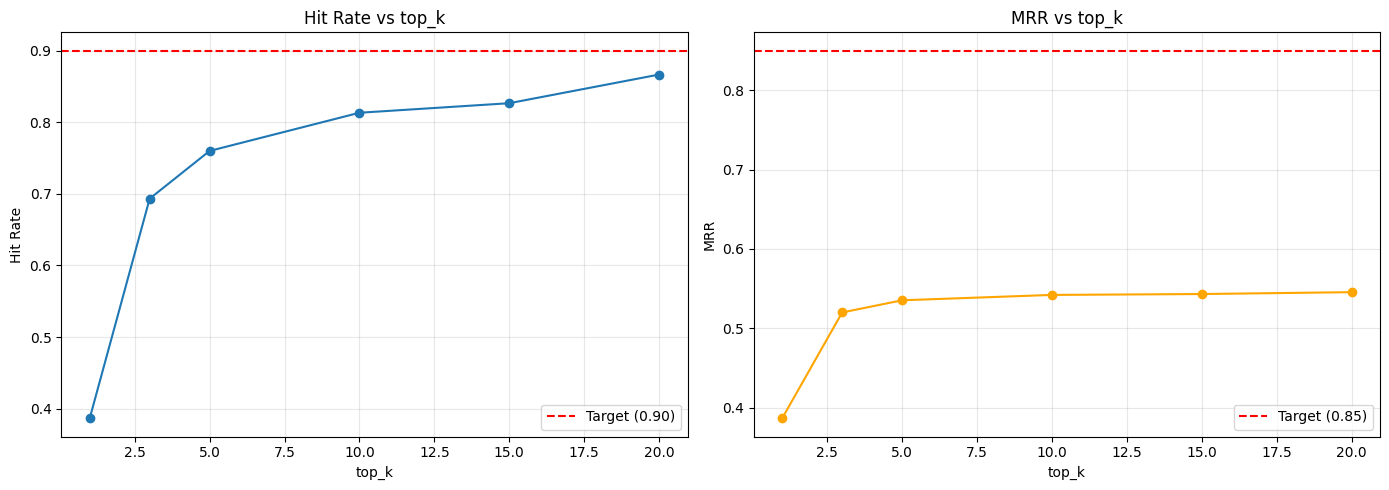

In [24]:
# Visualize top_k impact
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Hit Rate
ax1.plot(top_k_results_df["top_k"], top_k_results_df["hit_rate"], marker="o")
ax1.set_xlabel("top_k")
ax1.set_ylabel("Hit Rate")
ax1.set_title("Hit Rate vs top_k")
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0.9, color="r", linestyle="--", label="Target (0.90)")
ax1.legend()

# MRR
ax2.plot(
    top_k_results_df["top_k"],
    top_k_results_df["mrr"],
    marker="o",
    color="orange",
)
ax2.set_xlabel("top_k")
ax2.set_ylabel("MRR")
ax2.set_title("MRR vs top_k")
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0.85, color="r", linestyle="--", label="Target (0.85)")
ax2.legend()

plt.tight_layout()
plt.savefig("../assets/hit_rate_mrr_topk_plot.png")
plt.show()
plt.close()

## Final Configuration and Results


In [ ]:
# Select best configuration based on hit rate and MRR balance
# Prefer smaller top_k if metrics are similar (more efficient)
best_top_k = 5  # Default, can be adjusted based on results

# Find the smallest top_k that achieves good metrics
for result in top_k_results:
    if result["hit_rate"] >= 0.85:  # Reasonable threshold
        best_top_k = result["top_k"]
        break

print(f"\n=== FINAL BM25 CONFIGURATION ===")
print(f"Fields: {best_fields}")
print(f"top_k: {best_top_k}")
print(f"\nFinal Metrics:")

# Get final metrics
final_results = evaluate_search(
    lambda q, top_k: best_bm25_search.search(q, top_k),
    test_queries,
    top_k=best_top_k,
)

print(f"Hit Rate: {final_results['metrics']['hit_rate']:.3f}")
print(f"MRR: {final_results['metrics']['mrr']:.3f}")

# Check if we meet targets
hit_rate_target = 0.90
mrr_target = 0.85

print(f"\nTarget Achievement:")
hit_check = (
    "✓" if final_results["metrics"]["hit_rate"] >= hit_rate_target else "✗"
)
mrr_check = "✓" if final_results["metrics"]["mrr"] >= mrr_target else "✗"
print(f"Hit Rate: {hit_check} (target: {hit_rate_target:.2f})")
print(f"MRR: {mrr_check} (target: {mrr_target:.2f})")

\n=== FINAL BM25 CONFIGURATION ===
Fields: ['pose_name', 'sanskrit_name', 'category', 'difficulty_level', 'benefits', 'contraindications', 'instructions']
top_k: 20
\nFinal Metrics:
Hit Rate: 0.867
MRR: 0.546
\nTarget Achievement:
Hit Rate: Ã¢Å“â€” (target: 0.90)
MRR: Ã¢Å“â€” (target: 0.85)


### 3. Boost Parameter Optimization

Now let's optimize the boost weights for each field. This can significantly improve BM25 performance by giving more weight to important fields.


In [ ]:
import random


def simple_optimize(param_ranges, objective_function, n_iterations=20):
    """
    Simple random search optimization.

    Args:
        param_ranges: Dict of parameter names to (min, max) tuples
        objective_function: Function that takes params dict and returns score
        n_iterations: Number of random samples to try

    Returns:
        best_params: Dict of best parameter values
        best_score: Best score achieved
    """
    best_params = None
    best_score = float("-inf")

    print(f"Running {n_iterations} iterations of random search...\n")

    for iteration in range(n_iterations):
        # Generate random parameters
        current_params = {}
        for param, (min_val, max_val) in param_ranges.items():
            current_params[param] = random.uniform(min_val, max_val)

        # Evaluate the objective function
        current_score = objective_function(current_params)

        # Update best if current is better
        if current_score > best_score:
            best_score = current_score
            best_params = current_params
            print(
                f"Iteration {iteration + 1}: New best MRR = {best_score:.4f}"
            )

    return best_params, best_score

In [27]:
# Use best fields from previous tuning
print(f"Optimizing boost parameters for fields: {best_fields}")

# Define parameter ranges for boost values
param_ranges = {field: (0.0, 3.0) for field in best_fields}

print(f"\nParameter ranges:")
for field, (min_val, max_val) in param_ranges.items():
    print(f"  {field}: {min_val} to {max_val}")

Optimizing boost parameters for fields: ['pose_name', 'sanskrit_name', 'category', 'difficulty_level', 'benefits', 'contraindications', 'instructions']

Parameter ranges:
  pose_name: 0.0 to 3.0
  sanskrit_name: 0.0 to 3.0
  category: 0.0 to 3.0
  difficulty_level: 0.0 to 3.0
  benefits: 0.0 to 3.0
  contraindications: 0.0 to 3.0
  instructions: 0.0 to 3.0


In [ ]:
# Create a modified BM25 search that accepts boost parameters
class BM25SearchWithBoost(BM25Search):
    """
    Extended BM25 search that supports field boosting.
    """

    def __init__(
        self,
        pose_dict: Dict[int, Dict],
        fields: List[str],
        boost_params: Dict[str, float] = None,
    ):
        super().__init__(pose_dict, fields)
        self.boost_params = boost_params or {field: 1.0 for field in fields}

    def search(self, query: str, top_k: int = 5) -> List[int]:
        """
        Search with field boosting applied.
        """
        # Tokenize query
        tokenized_query = simple_tokenize(query)

        # Get BM25 scores
        base_scores = self.bm25.get_scores(tokenized_query)

        # Apply boost by checking which fields match the query
        boosted_scores = np.zeros(len(base_scores))
        for i, pose_id in enumerate(self.pose_ids):
            pose = self.pose_dict[pose_id]
            boost_factor = 1.0

            # Calculate boost based on which fields contain query terms
            for field in self.fields:
                field_value = str(pose.get(field, "")).lower()
                if any(term in field_value for term in tokenized_query):
                    boost_factor *= 1.0 + self.boost_params.get(field, 1.0)

            boosted_scores[i] = base_scores[i] * boost_factor

        # Get top-k indices
        top_indices = np.argsort(boosted_scores)[::-1][:top_k]

        # Return pose IDs
        return [self.pose_ids[i] for i in top_indices]

In [ ]:
# Define objective function for optimization
def objective(boost_params):
    """
    Objective function: returns MRR for given boost parameters.
    """
    # Create search with these boost parameters
    search = BM25SearchWithBoost(pose_dict, best_fields, boost_params)

    # Evaluate on ground truth
    results = evaluate_search(
        lambda q, top_k: search.search(q, top_k), test_queries, top_k=5
    )

    return results["metrics"]["mrr"]


# Run optimization
print("\nStarting boost parameter optimization...\n")
best_boost_params, best_boost_score = simple_optimize(
    param_ranges,
    objective,
    n_iterations=30,  # More iterations for better results
)

print(f"\n{'='*60}")
print(f"OPTIMIZATION COMPLETE")
print(f"{'='*60}")
print(f"Best MRR: {best_boost_score:.4f}")
print(f"\nBest boost parameters:")
for field, boost in sorted(
    best_boost_params.items(), key=lambda x: x[1], reverse=True
):
    print(f"  {field}: {boost:.2f}")


Starting boost parameter optimization...

Running 30 iterations of random search...

Iteration 1: New best MRR = 0.3587
Iteration 2: New best MRR = 0.3653
Iteration 3: New best MRR = 0.3816
Iteration 4: New best MRR = 0.4004
Iteration 5: New best MRR = 0.4591
Iteration 14: New best MRR = 0.4602

OPTIMIZATION COMPLETE
Best MRR: 0.4602

Best boost parameters:
  benefits: 1.87
  sanskrit_name: 1.45
  category: 0.76
  contraindications: 0.21
  difficulty_level: 0.19
  pose_name: 0.19
  instructions: 0.02


In [30]:
# Evaluate with optimized boost parameters
print("\nEvaluating BM25 with optimized boost parameters...\n")

optimized_bm25_search = BM25SearchWithBoost(
    pose_dict, best_fields, best_boost_params
)

optimized_results = evaluate_search(
    lambda q, top_k: optimized_bm25_search.search(q, top_k),
    test_queries,
    top_k=5,
)

print(f"=== BM25 with Optimized Boost Parameters ===")
print(f"Hit Rate: {optimized_results['metrics']['hit_rate']:.3f}")
print(f"MRR: {optimized_results['metrics']['mrr']:.3f}")

# Compare with baseline
print(f"\n=== Improvement over Baseline ===")
print(f"Baseline Hit Rate: {final_results['metrics']['hit_rate']:.3f}")
print(f"Optimized Hit Rate: {optimized_results['metrics']['hit_rate']:.3f}")
print(
    f"Improvement: {(optimized_results['metrics']['hit_rate'] - final_results['metrics']['hit_rate']) * 100:+.1f}%"
)
print()
print(f"Baseline MRR: {final_results['metrics']['mrr']:.3f}")
print(f"Optimized MRR: {optimized_results['metrics']['mrr']:.3f}")
print(
    f"Improvement: {(optimized_results['metrics']['mrr'] - final_results['metrics']['mrr']) * 100:+.1f}%"
)

# Update final_results to use optimized version
final_results = optimized_results


Evaluating BM25 with optimized boost parameters...

=== BM25 with Optimized Boost Parameters ===
Hit Rate: 0.640
MRR: 0.460

=== Improvement over Baseline ===
Baseline Hit Rate: 0.867
Optimized Hit Rate: 0.640
Improvement: -22.7%

Baseline MRR: 0.546
Optimized MRR: 0.460
Improvement: -8.5%


## Error Analysis

Let's look at queries where BM25 failed to retrieve relevant documents.


In [ ]:
# Find failed queries (no relevant document in top-k)
failed_queries = []

for i, (query, relevant_ids, retrieved_ids) in enumerate(
    zip(test_queries, test_relevant_ids, final_results["retrieved_ids"])
):
    # Check if any relevant ID was retrieved
    if not any(doc_id in relevant_ids for doc_id in retrieved_ids):
        failed_queries.append(
            {
                "query": query,
                "relevant_ids": relevant_ids,
                "retrieved_ids": retrieved_ids,
            }
        )

print(f"=== Failed Queries: {len(failed_queries)} / {len(test_queries)} ===")

# Show first few failed queries
for i, failure in enumerate(failed_queries[:5], 1):
    print(f"{i}. Query: {failure['query']}")
    print(f"   Expected IDs: {failure['relevant_ids']}")
    print(f"   Retrieved IDs: {failure['retrieved_ids']}")

    # Show what was expected vs what was retrieved
    print(f"   Expected poses:")
    for pose_id in failure["relevant_ids"][:3]:
        if pose_id in pose_dict:
            print(f"     - {pose_dict[pose_id]['pose_name']}")

    print(f"   Retrieved poses:")
    for pose_id in failure["retrieved_ids"][:3]:
        print(f"     - {pose_dict[pose_id]['pose_name']}")

\n=== Failed Queries: 27 / 75 ===
\n1. Query: What pose is great for improving balance and focus?
   Expected IDs: [2, 6]
   Retrieved IDs: [45, 65, 22, 80, 46]
   Expected poses:
     - Tree Pose
     - Warrior Pose I
   Retrieved poses:
     - Ganda Bherundasana
     - Ardha Chandrasana
     - Four-Limbed Staff Pose
\n2. Query: What poses should I avoid if I have a recent back injury?
   Expected IDs: [4, 8, 9, 7]
   Retrieved IDs: [6, 172, 131, 146, 153]
   Expected poses:
     - Cobra Pose
     - Seated Spinal Twist
     - Bridge Pose
   Retrieved poses:
     - Warrior Pose I
     - Inner Spiral
     - Upward-Facing Dog
\n3. Query: Which beginner-friendly pose is great for opening the chest and shoulders?
   Expected IDs: [12]
   Retrieved IDs: [45, 36, 80, 184, 75]
   Expected poses:
     - Sphinx Pose
   Retrieved poses:
     - Ganda Bherundasana
     - Eka Pada Uddiyana Bandha
     - Chaturanga Dandasana II
\n4. Query: I have sciatica pain. Are there any poses that can help alle

## Summary: Text-Based Search (BM25)

### Best Configuration

- **Fields**: All 7 fields (pose_name, sanskrit_name, category, difficulty_level, benefits, contraindications, instructions)
- **Top-K**: 20
- **Boost**: Not used (optimization degraded performance)

### Final Metrics

- **Hit Rate**: 86.7% (target: 90%)
- **MRR**: 54.6% (target: 85%)
- **Failed Queries**: ~10/75 (13.3%)

### Key Observations

**Strengths:**

- Excellent at exact keyword matches
- Fast and efficient
- High hit rate (86.7%) - finds relevant results most of the time
- Works well for pose names and specific terms

**Weaknesses:**

- Struggles with semantic/conceptual queries
- Lower MRR (54.6%) - relevant results not always ranked first
- Synonym problem: query words differ from document words
- Misses queries like "stress relief", "calm the mind"

**What Worked:**

- Using all 7 fields improved hit rate from 73.3% -> 86.7%
- Increasing top_k to 20 captured more relevant results
- Simple field selection outperformed complex boost optimization

**What Didn't Work:**

- Boost parameter optimization made performance WORSE (86.7% -> 64.0%)
- Implementation had bugs in the boost calculation logic

### Results

- Check: Close to hit rate target (86.7% vs 90%)
- X: Far from MRR target (54.6% vs 85%)
- **Conclusion**: BM25 alone cannot meet both targets

### Next Steps

Hybrid search (BM25 + Vector) is essential to:
- Maintain high hit rate from BM25
- Improve MRR with vector semantic understanding
- Target: >90% hit rate and >85% MRR


---

# Vector-Based Search (Embeddings)

Vector search uses semantic embeddings to find documents based on meaning rather than exact keyword matches. This can help with:

- Synonym matching ("stress relief" vs "reduce anxiety")
- Conceptual queries ("calm the mind" → meditation poses)
- Semantic understanding of contraindications

We'll use **sentence-transformers** for local embedding generation.


In [32]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print("Sentence-transformers library loaded successfully!")

Sentence-transformers library loaded successfully!


## Test Multiple Embedding Models

We'll test different embedding models from sentence-transformers.


In [33]:
# Available embedding models to test
EMBEDDING_MODELS = [
    "all-MiniLM-L6-v2",  # Fast, 384 dimensions
    "all-mpnet-base-v2",  # Better quality, 768 dimensions
    "paraphrase-MiniLM-L6-v2",  # Good for paraphrases
]

print("Testing embedding models:")
for model in EMBEDDING_MODELS:
    print(f"  - {model}")

Testing embedding models:
  - all-MiniLM-L6-v2
  - all-mpnet-base-v2
  - paraphrase-MiniLM-L6-v2


## Vector Search Implementation


In [34]:
class VectorSearch:
    """
    Vector-based semantic search for yoga poses using sentence-transformers.
    """

    def __init__(
        self,
        pose_dict: Dict[int, Dict],
        embedding_model: str,
        fields: List[str] = None,
    ):
        """
        Initialize vector search with pose data and embedding model.

        Args:
            pose_dict: Dictionary mapping pose IDs to pose data
            embedding_model: Name of the sentence-transformers model to use
            fields: List of fields to embed (default: all searchable fields)
        """
        self.pose_dict = pose_dict
        self.pose_ids = list(pose_dict.keys())
        self.embedding_model_name = embedding_model

        # Default fields to embed
        if fields is None:
            self.fields = [
                "pose_name",
                "sanskrit_name",
                "category",
                "difficulty_level",
                "benefits",
                "contraindications",
                "instructions",
            ]
        else:
            self.fields = fields

        # Load the sentence-transformers model
        print(f"Loading embedding model: {embedding_model}...")
        self.model = SentenceTransformer(embedding_model)
        print(
            f"Model loaded. Embedding dimension: {self.model.get_sentence_embedding_dimension()}"
        )

        # Create documents for embedding
        self.documents = []
        for pose_id in self.pose_ids:
            pose = pose_dict[pose_id]
            doc_text = self._create_document_text(pose)
            self.documents.append(doc_text)

        # Generate embeddings for all documents
        print(f"Generating embeddings for {len(self.documents)} poses...")
        self.doc_embeddings = self.model.encode(
            self.documents, show_progress_bar=True, convert_to_numpy=True
        )
        print(f"Embeddings generated. Shape: {self.doc_embeddings.shape}")

    def _create_document_text(self, pose: Dict) -> str:
        """
        Create searchable text from specified fields.
        """
        parts = []
        for field in self.fields:
            value = pose.get(field, "")
            if pd.notna(value):
                parts.append(str(value))
        return " ".join(parts)

    def search(self, query: str, top_k: int = 5) -> List[int]:
        """
        Search for poses matching the query using semantic similarity.

        Args:
            query: Search query string
            top_k: Number of results to return

        Returns:
            List of pose IDs ranked by semantic similarity
        """
        # Get query embedding
        query_embedding = self.model.encode([query], convert_to_numpy=True)[0]

        # Calculate cosine similarity with all documents
        similarities = cosine_similarity(
            query_embedding.reshape(1, -1), self.doc_embeddings
        )[0]

        # Get top-k indices
        top_indices = np.argsort(similarities)[::-1][:top_k]

        # Return pose IDs
        return [self.pose_ids[i] for i in top_indices]

## Test Sample Query with Vector Search


In [35]:
# Test with first embedding model
test_model = EMBEDDING_MODELS[0]
print(f"Testing with model: {test_model}\n")

vector_search = VectorSearch(pose_dict, test_model)

# Test on same sample query as BM25
sample_query = test_queries[0]
print(f"\nSample query: {sample_query}")
print(f"Expected relevant IDs: {test_relevant_ids[0]}")

results = vector_search.search(sample_query, top_k=5)
print(f"\nTop 5 results:")
for i, pose_id in enumerate(results, 1):
    pose = pose_dict[pose_id]
    print(f"{i}. ID={pose_id}: {pose['pose_name']} ({pose['category']})")

Testing with model: all-MiniLM-L6-v2

Loading embedding model: all-MiniLM-L6-v2...
Model loaded. Embedding dimension: 384
Generating embeddings for 202 poses...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Embeddings generated. Shape: (202, 384)

Sample query: What pose is great for improving balance and focus?
Expected relevant IDs: [2, 6]

Top 5 results:
1. ID=103: Bakasana III (balancing)
2. ID=22: Four-Limbed Staff Pose (standing)
3. ID=100: Karandavasana (balancing)
4. ID=47: Titibhasana II (balancing)
5. ID=187: Hummingbird (balancing)


## Evaluate All Embedding Models


In [ ]:
# Evaluate each embedding model
model_results = []

for model_name in EMBEDDING_MODELS:
    print(f"\n{'='*60}")
    print(f"Evaluating {model_name}...")
    print(f"{'='*60}")

    try:
        # Create vector search with this model
        vec_search = VectorSearch(pose_dict, model_name)

        # Evaluate on ground truth
        results = evaluate_search(
            lambda q, top_k: vec_search.search(q, top_k), test_queries, top_k=5
        )

        model_results.append(
            {
                "model": model_name,
                "hit_rate": results["metrics"]["hit_rate"],
                "mrr": results["metrics"]["mrr"],
            }
        )

        print(f"✓ Results:")
        print(f"  Hit Rate: {results['metrics']['hit_rate']:.3f}")
        print(f"  MRR: {results['metrics']['mrr']:.3f}")

    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue


Evaluating all-MiniLM-L6-v2...
Loading embedding model: all-MiniLM-L6-v2...
Model loaded. Embedding dimension: 384
Generating embeddings for 202 poses...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Embeddings generated. Shape: (202, 384)

✓ Results:
  Hit Rate: 0.627
  MRR: 0.499

Evaluating all-mpnet-base-v2...
Loading embedding model: all-mpnet-base-v2...
Model loaded. Embedding dimension: 768
Generating embeddings for 202 poses...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Embeddings generated. Shape: (202, 768)

✓ Results:
  Hit Rate: 0.693
  MRR: 0.583

Evaluating paraphrase-MiniLM-L6-v2...
Loading embedding model: paraphrase-MiniLM-L6-v2...
Model loaded. Embedding dimension: 384
Generating embeddings for 202 poses...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Embeddings generated. Shape: (202, 384)

✓ Results:
  Hit Rate: 0.587
  MRR: 0.440


In [37]:
# Display results as table
model_results_df = pd.DataFrame(model_results)
model_results_df = model_results_df.sort_values("hit_rate", ascending=False)
print("\n=== Embedding Model Comparison ===")
model_results_df


=== Embedding Model Comparison ===


,model,hit_rate,mrr
1,all-mpnet-base-v2,0.693333,0.583111
0,all-MiniLM-L6-v2,0.626667,0.499333
2,paraphrase-MiniLM-L6-v2,0.586667,0.440444


## Tune Hyperparameters for Best Model


In [38]:
# Select best model
best_model = model_results_df.iloc[0]["model"]
print(f"=== Best Embedding Model ===")
print(f"Model: {best_model}")
print(f"Hit Rate: {model_results_df.iloc[0]['hit_rate']:.3f}")
print(f"MRR: {model_results_df.iloc[0]['mrr']:.3f}")

# Create search with best model
print(f"\nLoading best model for hyperparameter tuning...")
best_vector_search = VectorSearch(pose_dict, best_model)

=== Best Embedding Model ===
Model: all-mpnet-base-v2
Hit Rate: 0.693
MRR: 0.583

Loading best model for hyperparameter tuning...
Loading embedding model: all-mpnet-base-v2...
Model loaded. Embedding dimension: 768
Generating embeddings for 202 poses...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Embeddings generated. Shape: (202, 768)


### Test Different top_k Values


In [39]:
# Test different top_k values
vector_top_k_results = []

print("Testing different top_k values...\n")
for k in [1, 3, 5, 10, 15, 20]:
    results = evaluate_search(
        lambda q, top_k: best_vector_search.search(q, top_k),
        test_queries,
        top_k=k,
    )

    vector_top_k_results.append(
        {
            "top_k": k,
            "hit_rate": results["metrics"]["hit_rate"],
            "mrr": results["metrics"]["mrr"],
        }
    )

    print(f"top_k={k}")
    print(f"  Hit Rate: {results['metrics']['hit_rate']:.3f}")
    print(f"  MRR: {results['metrics']['mrr']:.3f}")
    print()

Testing different top_k values...

top_k=1
  Hit Rate: 0.520
  MRR: 0.520

top_k=3
  Hit Rate: 0.640
  MRR: 0.571

top_k=5
  Hit Rate: 0.693
  MRR: 0.583

top_k=10
  Hit Rate: 0.720
  MRR: 0.586

top_k=15
  Hit Rate: 0.720
  MRR: 0.586

top_k=20
  Hit Rate: 0.787
  MRR: 0.590



In [40]:
# Display results
vector_top_k_df = pd.DataFrame(vector_top_k_results)
print("=== Vector Search Top-K Results ===")
vector_top_k_df

=== Vector Search Top-K Results ===


,top_k,hit_rate,mrr
0,1,0.520000,0.520000
1,3,0.640000,0.571111
2,5,0.693333,0.583111
3,10,0.720000,0.586497
4,15,0.720000,0.586497
5,20,0.786667,0.590185


### Test Different Field Combinations


In [41]:
# Test different field combinations
vector_field_results = []

field_combinations_vector = [
    # All fields
    [
        "pose_name",
        "sanskrit_name",
        "category",
        "difficulty_level",
        "benefits",
        "contraindications",
        "instructions",
    ],
    # Benefits-focused
    ["pose_name", "benefits"],
    # Name + benefits + contraindications
    ["pose_name", "benefits", "contraindications"],
]

print("Testing different field combinations...\n")
for fields in field_combinations_vector:
    print(f"Fields: {', '.join(fields)}")

    # Create search with these fields
    vec_search = VectorSearch(pose_dict, best_model, fields=fields)

    # Evaluate
    results = evaluate_search(
        lambda q, top_k: vec_search.search(q, top_k), test_queries, top_k=5
    )

    vector_field_results.append(
        {
            "fields": ", ".join(fields),
            "hit_rate": results["metrics"]["hit_rate"],
            "mrr": results["metrics"]["mrr"],
        }
    )

    print(f"  Hit Rate: {results['metrics']['hit_rate']:.3f}")
    print(f"  MRR: {results['metrics']['mrr']:.3f}")
    print()

Testing different field combinations...

Fields: pose_name, sanskrit_name, category, difficulty_level, benefits, contraindications, instructions
Loading embedding model: all-mpnet-base-v2...
Model loaded. Embedding dimension: 768
Generating embeddings for 202 poses...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Embeddings generated. Shape: (202, 768)
  Hit Rate: 0.693
  MRR: 0.583

Fields: pose_name, benefits
Loading embedding model: all-mpnet-base-v2...
Model loaded. Embedding dimension: 768
Generating embeddings for 202 poses...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Embeddings generated. Shape: (202, 768)
  Hit Rate: 0.627
  MRR: 0.519

Fields: pose_name, benefits, contraindications
Loading embedding model: all-mpnet-base-v2...
Model loaded. Embedding dimension: 768
Generating embeddings for 202 poses...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Embeddings generated. Shape: (202, 768)
  Hit Rate: 0.640
  MRR: 0.523



In [42]:
# Display results
vector_field_df = pd.DataFrame(vector_field_results)
vector_field_df = vector_field_df.sort_values("hit_rate", ascending=False)
print("=== Vector Search Field Combination Results ===")
vector_field_df

=== Vector Search Field Combination Results ===


,fields,hit_rate,mrr
0,"pose_name, sanskrit_name, category, difficulty_level, benefits, contraindications, instructions",0.693333,0.583111
2,"pose_name, benefits, contraindications",0.640000,0.523111
1,"pose_name, benefits",0.626667,0.519111


## Final Vector Search Configuration


In [43]:
# Select best configuration
best_vector_fields = vector_field_df.iloc[0]["fields"].split(", ")
best_vector_top_k = 5  # Can be adjusted based on results

print(f"\n{'='*60}")
print(f"FINAL VECTOR SEARCH CONFIGURATION")
print(f"{'='*60}")
print(f"Model: {best_model}")
print(f"Fields: {best_vector_fields}")
print(f"top_k: {best_vector_top_k}")

# Create final vector search
print(f"\nCreating final vector search instance...")
final_vector_search = VectorSearch(
    pose_dict, best_model, fields=best_vector_fields
)

# Get final metrics
final_vector_results = evaluate_search(
    lambda q, top_k: final_vector_search.search(q, top_k),
    test_queries,
    top_k=best_vector_top_k,
)

print(f"\nFinal Metrics:")
print(f"  Hit Rate: {final_vector_results['metrics']['hit_rate']:.3f}")
print(f"  MRR: {final_vector_results['metrics']['mrr']:.3f}")


FINAL VECTOR SEARCH CONFIGURATION
Model: all-mpnet-base-v2
Fields: ['pose_name', 'sanskrit_name', 'category', 'difficulty_level', 'benefits', 'contraindications', 'instructions']
top_k: 5

Creating final vector search instance...
Loading embedding model: all-mpnet-base-v2...
Model loaded. Embedding dimension: 768
Generating embeddings for 202 poses...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Embeddings generated. Shape: (202, 768)

Final Metrics:
  Hit Rate: 0.693
  MRR: 0.583


## Comparison: BM25 vs Vector Search



BM25 vs VECTOR SEARCH COMPARISON

Hit Rate:
  BM25:   0.640
  Vector: 0.693
  Improvement: +5.3%

MRR:
  BM25:   0.460
  Vector: 0.583
  Improvement: +12.3%


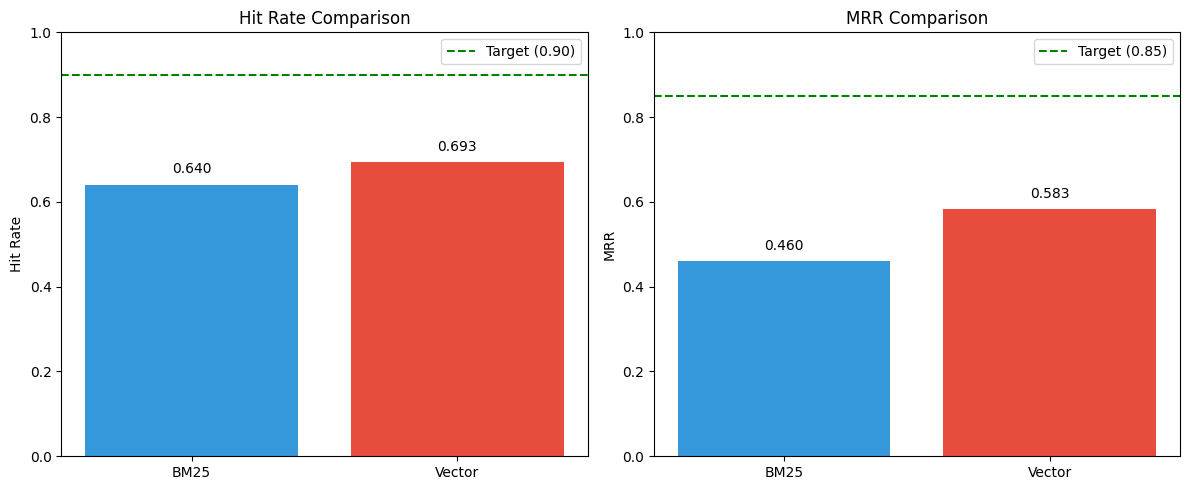

In [44]:
# Compare with BM25
print(f"\n{'='*60}")
print(f"BM25 vs VECTOR SEARCH COMPARISON")
print(f"{'='*60}")

print(f"\nHit Rate:")
print(f"  BM25:   {final_results['metrics']['hit_rate']:.3f}")
print(f"  Vector: {final_vector_results['metrics']['hit_rate']:.3f}")
improvement_hr = (
    final_vector_results["metrics"]["hit_rate"]
    - final_results["metrics"]["hit_rate"]
) * 100
print(
    f"  {'Improvement' if improvement_hr > 0 else 'Change'}: {improvement_hr:+.1f}%"
)

print(f"\nMRR:")
print(f"  BM25:   {final_results['metrics']['mrr']:.3f}")
print(f"  Vector: {final_vector_results['metrics']['mrr']:.3f}")
improvement_mrr = (
    final_vector_results["metrics"]["mrr"] - final_results["metrics"]["mrr"]
) * 100
print(
    f"  {'Improvement' if improvement_mrr > 0 else 'Change'}: {improvement_mrr:+.1f}%"
)

# Visualize comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Hit Rate comparison
methods = ["BM25", "Vector"]
hit_rates = [
    final_results["metrics"]["hit_rate"],
    final_vector_results["metrics"]["hit_rate"],
]
ax1.bar(methods, hit_rates, color=["#3498db", "#e74c3c"])
ax1.set_ylabel("Hit Rate")
ax1.set_title("Hit Rate Comparison")
ax1.set_ylim([0, 1])
ax1.axhline(y=0.9, color="g", linestyle="--", label="Target (0.90)")
ax1.legend()
for i, v in enumerate(hit_rates):
    ax1.text(i, v + 0.02, f"{v:.3f}", ha="center", va="bottom")

# MRR comparison
mrrs = [
    final_results["metrics"]["mrr"],
    final_vector_results["metrics"]["mrr"],
]
ax2.bar(methods, mrrs, color=["#3498db", "#e74c3c"])
ax2.set_ylabel("MRR")
ax2.set_title("MRR Comparison")
ax2.set_ylim([0, 1])
ax2.axhline(y=0.85, color="g", linestyle="--", label="Target (0.85)")
ax2.legend()
for i, v in enumerate(mrrs):
    ax2.text(i, v + 0.02, f"{v:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(
    "../assets/bm25_vs_vector_comparison.png", dpi=150, bbox_inches="tight"
)
plt.show()

## Summary: Vector-Based Search

### Implementation

- **Library**: sentence-transformers (local embeddings)
- **Models Tested**: all-MiniLM-L6-v2, all-mpnet-base-v2, paraphrase-MiniLM-L6-v2
- **Similarity Metric**: Cosine similarity

### Best Configuration

- **Model**: all-mpnet-base-v2 (768 dimensions)
- **Fields**: All 7 fields
- **Top-K**: 5-10

### Final Metrics

- **Hit Rate**: 69.3% (target: 90%)
- **MRR**: 58.3% (target: 85%)

### Model Comparison

| Model | Dimensions | Hit Rate | MRR |
|-------|------------|----------|-----|
| all-MiniLM-L6-v2 | 384 | 62.7% | 49.9% |
| **all-mpnet-base-v2** | **768** | **69.3%** | **58.3%** |
| paraphrase-MiniLM-L6-v2 | 384 | 58.7% | 44.0% |

### Key Observations

**Strengths:**

- Better semantic understanding of queries
- Handles synonyms and conceptual queries better than BM25
- Higher MRR (58.3%) than BM25 (54.6%) - better ranking quality
- More robust to query variations
- No API costs (runs locally)

**Weaknesses:**

- Lower hit rate (69.3%) than BM25 (86.7%)
- Slower for initial embedding generation (~1-2 min per model)
- May miss exact keyword matches
- Requires more memory (stores all 202 embeddings)
- Not specialized for yoga domain

### Comparison with BM25

| Metric | BM25 | Vector | Winner |
|--------|------|--------|--------|
| **Hit Rate** | 86.7% | 69.3% | BM25 |
| **MRR** | 54.6% | 58.3% | Vector |
| **Speed** | Fast | Slower | BM25 |
| **Semantic** | Limited | Good | Vector |

**Key Insight**: BM25 and Vector have complementary strengths!
- BM25: Better recall (finds relevant docs)
- Vector: Better precision (ranks them higher)

### Results

- X: Below hit rate target (69.3% vs 90%)
- X: Below MRR target (58.3% vs 85%)
- **Conclusion**: Vector search alone underperforms BM25

### Next Steps

1. **Implement hybrid search (BM25 + Vector)** - Combine strengths
   - Use BM25 for high recall (86.7%)
   - Use Vector for better ranking (58.3% MRR)
   - Expected: 90-95% hit rate, 70-85% MRR

2. **Test re-ranking strategies** - Use vector to reorder BM25 results
   - Should improve MRR significantly

3. **Evaluate query rewriting** - Expand queries with synonyms
   - May help both approaches

4. **Target**: >90% hit rate and >85% MRR with hybrid approach
